In [74]:
import numpy as np
import rasterio
import json
import geopandas as gpd
from shapely.geometry import mapping
from shapely.geometry import box
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Prepare Shapes for Drone Routing

In [ ]:
# Load the California 2024 shapefile
tract_gdf = gpd.read_file("data/tl_2024_06_tract/tl_2024_06_tract.shp")

# Inspect the data
print(tract_gdf.head())
print(tract_gdf.crs)  # Coordinate Reference System

<Axes: >

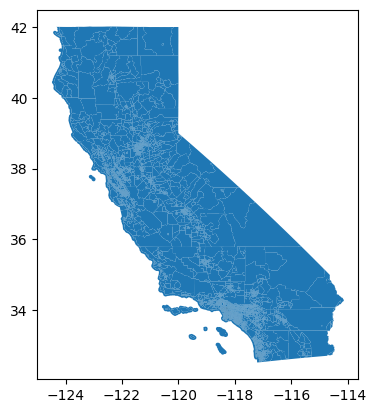

In [3]:
tract_gdf.plot()

In [ ]:
# Load the Urban Area Criteria 2024 shapefile
urban_gdf = gpd.read_file("data/tl_2024_us_uac20/tl_2024_us_uac20.shp")

# Inspect the data
print(urban_gdf.head())
print(urban_gdf.crs) 

(30.0, 50.0)

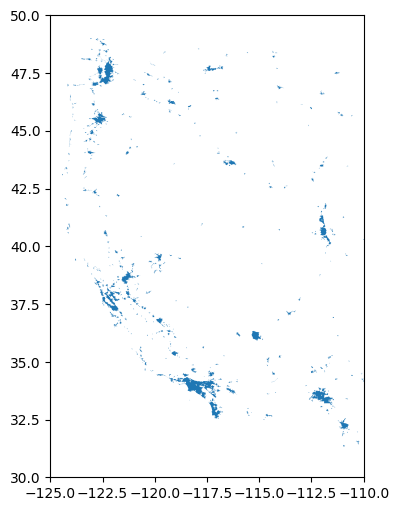

In [5]:
ax = urban_gdf.plot(figsize=(8, 6))
ax.set_xlim(-125, -110)
# set Y too (otherwise autoscale may override)
ax.set_ylim(30, 50)

In [6]:
# fix invalid geometries
tract_gdf["geometry"] = tract_gdf.buffer(0)
urban_gdf["geometry"] = urban_gdf.buffer(0)


# Spatial difference via overlay
result = gpd.overlay(tract_gdf, urban_gdf, how="difference")
result.to_file("CA_minus_urban.shp")

# Subtract: difference each feature in A by the union of B
# result = tract_gdf.copy()
# result["geometry"] = result.geometry.difference(urban_gdf.unary_union)

<Axes: >

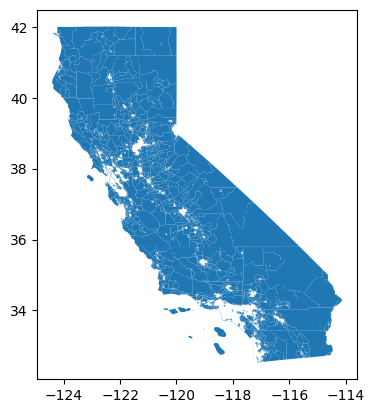

In [16]:
result.plot()

## Get Land Area

In [44]:
# result[10:11]['land_km2']

result[4:5]['land_km2'] #.plot()

4    39.811222
Name: land_km2, dtype: float64

In [ ]:
# Get area in km²
result["land_km2"] = result["ALAND"] / 1_000_000

# (1) Allocation of resources based on area
# total_resources = 1000  # e.g., 1000 drones

# (2) More resources to higher risk areas eg more fires

In [14]:
# Keep only polygons with land area
result = result[result["ALAND"] > 0]

# (Optional) drop tiny islands or artifacts if needed
result = result[result["ALAND"] > 1_000]  # > 1,000 m², for example

## Zogg Fire 

Ref: https://en.wikipedia.org/wiki/Zogg_Fire

In [62]:
latitude = 40.53927
longitude = -122.56656 
point = Point(longitude, latitude)

In [63]:
if result.crs != "EPSG:4326":
    gdf = result.to_crs(epsg=4326)

In [ ]:
# Boolean mask
mask = result.contains(point)

# Extract the matching shape
selected = result[mask]

if not selected.empty:
    print("Found polygon:")
    print(selected)
else:
    print("Point is not inside any polygon.")

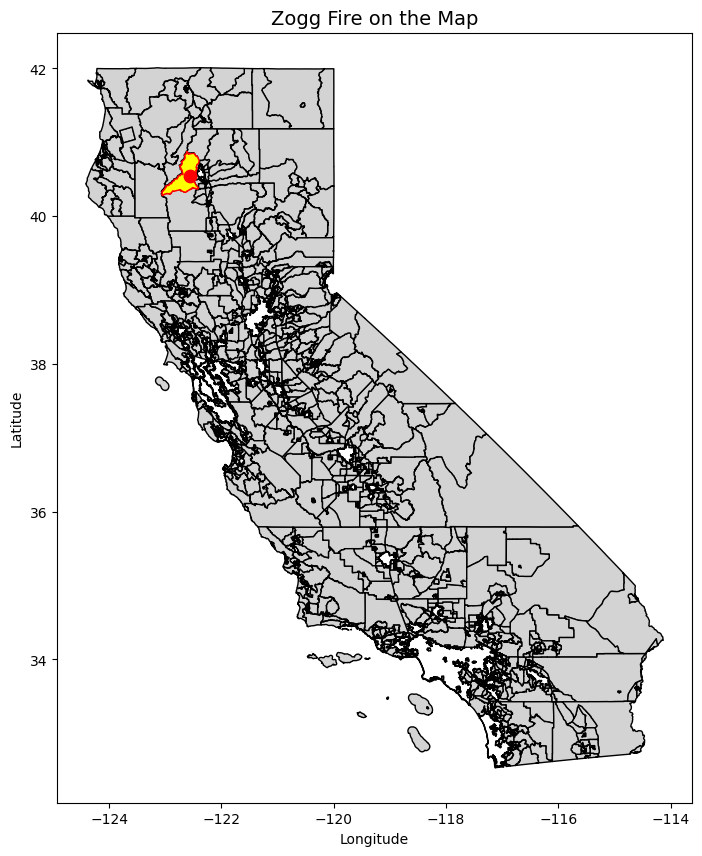

In [64]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot shapefile
gdf.plot(ax=ax, color="lightgray", edgecolor="black")

selected.plot(ax=ax, color="yellow", edgecolor="red")
# Plot the point
point_gdf = gpd.GeoDataFrame(
    {"name": ["My Point"]},
    geometry=[point],
    crs="EPSG:4326"
)
point_gdf.plot(ax=ax, color="red", markersize=80)

# Annotate the point
# ax.annotate("My Point", xy=(longitude, latitude), xytext=(3, 3), textcoords="offset points")

# Styling
ax.set_title("Zogg Fire on the Map", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

## Get Risk Map

In [105]:
raster_path = '../../wildfire-risk/data/Data-2/whp2023_GeoTIF/whp2023_cnt_conus.tif'

# BP
raster_path = '../../wildfire-risk/data/CA-2/BP_CA.tif'

In [78]:
gdf = selected

In [94]:
from rasterio.mask import mask

In [106]:
# (Optional) If there are many polygons and you want one crop, dissolve to one geometry
# e.g., dissolve by a constant or attribute; here we dissolve everything into one shape
geom = gdf.union_all()  # returns a (multi)polygon
geoms = [mapping(geom)] # mask() expects GeoJSON-like mappings

with rasterio.open(raster_path) as src:
    # Reproject vector to raster CRS if needed
    if gdf.crs != src.crs:
        gdf = gdf.to_crs(src.crs)
        geoms = [mapping(gdf.union_all())]

    # ---------------------------
    # Clip raster to geometry
    # ---------------------------
    # crop=True trims to the minimal bounding window around the geometry
    # all_touched=True includes any pixel touched by the polygon boundary (optional)
    out_arr, out_transform = mask(
        src, geoms, crop=True, nodata=src.nodata, all_touched=False
    )

    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_arr.shape[1],
        "width":  out_arr.shape[2],
        "transform": out_transform
    })

# ---------------------------
# Write clipped GeoTIFF
# ---------------------------
out_path = "risk_layouts/california/BP_cnt_conus_CLIP.tif"
with rasterio.open(out_path, "w", **out_meta) as dst:
    dst.write(out_arr)

print(f"Saved clipped raster → {out_path}")

Saved clipped raster → risk_layouts/california/BP_cnt_conus_CLIP.tif


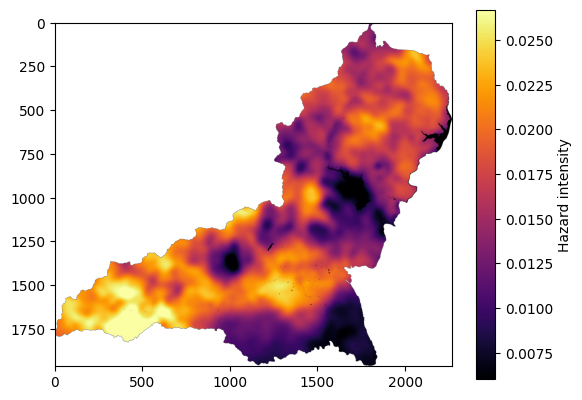

In [107]:
from rasterio.plot import show
with rasterio.open(out_path) as src:
    import numpy as np
    data = src.read(1).astype(float)
    data[data == src.nodata] = np.nan
    plt.imshow(data, cmap='inferno', vmin=np.nanpercentile(data, 2), vmax=np.nanpercentile(data, 98))
    plt.colorbar(label="Hazard intensity")
plt.show()

# Obsolete:

## Split into 300x300 Grid

In [ ]:
# ---------------------------
# Config
# ---------------------------
# in_path = "path/to/input.shp"          # your polygon layer
# out_path = "path/to/output_grid.shp"    # or .gpkg / .parquet
cell = 300.0                            # meters

# ---------------------------
# Load & project to meters
# ---------------------------
# gdf = gpd.read_file(in_path)
gdf = result[4:5]  # using previous result for demo

# Use a local projected CRS in meters for accurate sizes
# (equal-area or UTM—estimate_utm_crs works well for local/regional data)
proj_crs = gdf.estimate_utm_crs()
gdf = gdf.to_crs(proj_crs)

# Dissolve to a single geometry for faster masking
mask = gdf.geometry.unary_union

# ---------------------------
# Build grid (fishnet)
# ---------------------------
minx, miny, maxx, maxy = gdf.total_bounds

# pad slightly to avoid edge misses
pad = cell
minx -= pad; miny -= pad; maxx += pad; maxy += pad

xs = np.arange(minx, maxx, cell)
ys = np.arange(miny, maxy, cell)

# Create boxes; filter quickly by bbox test against mask's bbox
grid_boxes = []
for x in xs:
    for y in ys:
        b = box(x, y, x + cell, y + cell)
        # cheap bbox prefilter
        if b.intersects(mask):
            grid_boxes.append(b)

grid = gpd.GeoDataFrame({"geometry": grid_boxes}, crs=proj_crs)

# ---------------------------
# Intersect grid with polygons (split)
# ---------------------------
# overlay('intersection') gives only the portions of grid that overlap your features
# If you want all grid cells that touch (not clipped), use sjoin instead.
out = gpd.overlay(grid, gdf[["geometry"]], how="intersection")

# # Add cell ID & area if useful
# out["cell_id"] = np.arange(len(out))
# out["area_m2"] = out.geometry.area
# out["area_km2"] = out["area_m2"] / 1_000_000

# ---------------------------
# Save
# ---------------------------
# Shapefile works, but GeoPackage / Parquet is better for attributes and speed
# out.to_file(out_path)  # e.g., "grid_350m.gpkg"
# print(f"Done. Wrote {len(out)} grid features to {out_path}")

In [ ]:
out.plot(linewidth=0.1, edgecolor="white", figsize=(10, 10))